<a href="https://colab.research.google.com/github/formacionCDIA/cursoCDIA/blob/main/Notebooks/8_Introducci%C3%B3n_a_las_Redes_Neuronales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# **Análisis de datos y aprendizaje automático**
---


#**8.Introducción a las Redes Neuronales**
---


## 🎯Perceptrón simple y multicapa

### 🥇 Perceptrón

El perceptrón es una de las estructuras más simples de redes neuronales y fue introducido por Frank Rosenblatt en 1958.

* Toma varias entradas, las multiplica por algunos pesos y luego produce una salida.
* La salida es una función de activación (generalmente una función escalón) aplicada a la suma ponderada de sus entradas.
* Representa una única función discriminante que separa linealmente los ejemplos en dos clases.

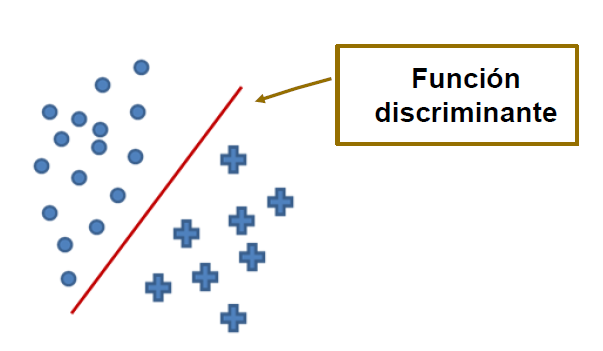

Considerando
$$
y=
\begin{cases}
 1& \text{ si} & neta >=\theta \\
 0& \text{ si} & neta <\theta
\end{cases}
$$

$$
neta = \sum_{i}x_iw_i
$$

Donde:

* w es el vector de pesos.
* x es el vector de entrada.

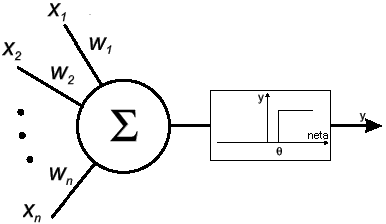

Verifiquemos si la siguiente red neuronal se comporta como una Función lógica AND

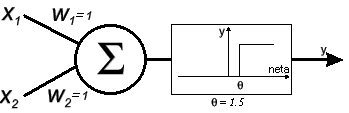

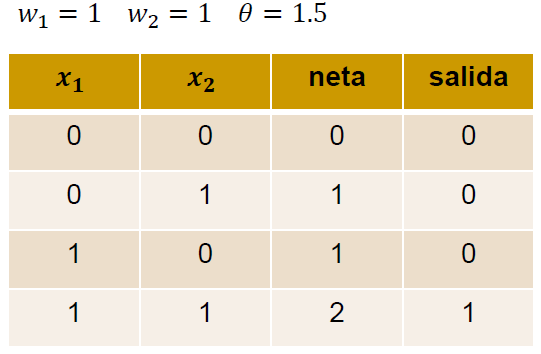

Si tenemos que:
$$
neta = \sum_{i}x_iw_i
$$

Entonces:

$$
x_1w_1+x_2w_2=\theta
$$

Reemplazando:


$$
x_1+x_2=1.5
$$

Graficando

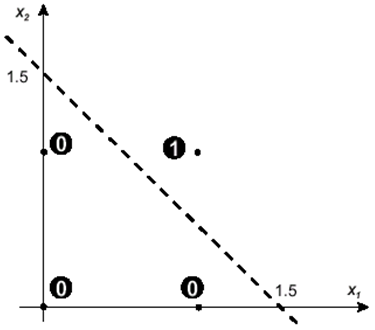

#### Entrenamiento del perceptrón

* Se busca una estrategia iterativa que permita adaptar los
valores de las conexiones a medida que se presentan los
datos de entrada.
* Ver que el estímulo de entrada se corresponde con el
producto interior de los vectors X y W.

**Producto Interno**

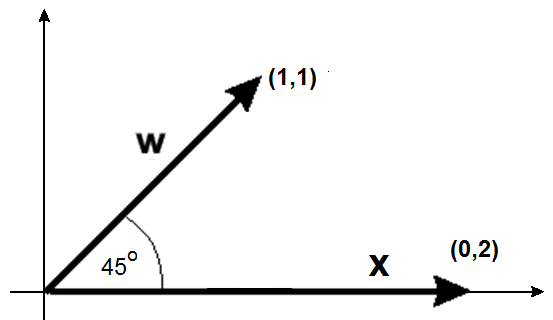


$$
w\cdot x = || w || . || x || . cos(Φ)
$$

$$
w ⋅ x = \sum_{i=1}^{n}w_ix_i
$$

Proceso:

1. Inicializar los pesos de las conexiones con valores random (vector W)
2. Mientras no se clasifiquen todos los ejemplos correctamente:
  1. Ingresar un ejemplo a la red.
  2. Si fue clasificado incorrectamente:
    1. Si esperaba obtener W.X > θ y no lo logró, “acerqué" el vector W al vector X.
    2. Si esperaba obtener W.X < θ y no lo logró, "alejé" el vector W al vector X.



#### Ajuste del vector de pesos

* Si W.X < Θ no es el valor esperado entonces acerque W a X de
la siguiente forma:
$$
w'=w+\alpha x
$$
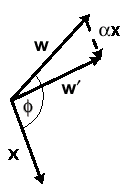


* Si W.X > Θ no es el valor esperado entonces aleje W de X de la siguiente forma:

$$
w'=w-\alpha x
$$

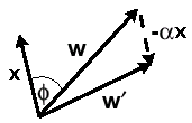

$\alpha$ es un valor real perteneciente a $(0,1]$

De esta forma, la actualización de los pesos puede calcularse como:

$$
w_{nuevo}=w+\alpha (t-y) x
$$

Dónde:
* $t$ es el valor esperado
* $y$ es el valor obtenido


De esta forma:

* Si $t=1$ e $y=0$

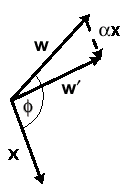

* Si $t=0$ e $y=1$

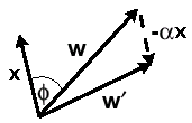

**Entrenamiento del Perceptrón**

1. Seleccionar el valor de $\alpha$ y $θ$
2. Inicializar los pesos de las conexiones con valores random (vector W)
3. Mientras no se clasifiquen todos los ejemplos correctamente
  1. Ingresar un ejemplo a la red.
  2. Si fue clasificado incorrectamente
    * $w_{nuevo}=w+\alpha (t-y)x$

***Ejemplo***

Entrenar un perceptrón para que se comporte como la función lógica AND, utilizando:

* $\alpha=0.3$
* $\theta=1.5$
* $w_1=0$
* $w_2=0.25$

In [1]:
import numpy as np
from matplotlib import pyplot as plt

entradas = np.array([[0,0], [0,1],[1,0],[1,1]])
salida = np.array([0,0,0,1])

nCantEjemplos = entradas.shape[0]  # nro. de filas
nAtrib = entradas.shape[1]         #nro. de columnas

sesgo = 0
W = np.array([0, 0.25])
theta = 1.5


MAX_ITE = 100
alfa = 0.1
hubo_cambio=True
ite=0
while (hubo_cambio and (ite<MAX_ITE)):
    hubo_cambio=False
    ite = ite + 1
    print(ite)
    # para cada intancia
    for i in range(nCantEjemplos):
        # Calcular la salida
        neta=0
        for j in range(nAtrib):
             neta = neta + W[j] * entradas[i,j]
        # y = 1 if neta >= theta else 0
        neta = neta + sesgo
        if neta >= theta:
          y = 1
        else:
          y = 0
        # ver si la respuesta es correcta, sino hay que corregir
        if not(y == salida[i]):
            hubo_cambio=True
            #    actualizamos los pesos W y b
            for j in range(nAtrib):
                W[j] = W[j] + alfa * (salida[i]-y) * entradas[i,j]
            sesgo =  sesgo + alfa * (salida[i]-y)

        print(entradas[i], salida[i], W, y,sesgo, neta)



1
[0 0] 0 [0.   0.25] 0 0 0.0
[0 1] 0 [0.   0.25] 0 0 0.25
[1 0] 0 [0.   0.25] 0 0 0.0
[1 1] 1 [0.1  0.35] 0 0.1 0.25
2
[0 0] 0 [0.1  0.35] 0 0.1 0.1
[0 1] 0 [0.1  0.35] 0 0.1 0.44999999999999996
[1 0] 0 [0.1  0.35] 0 0.1 0.2
[1 1] 1 [0.2  0.45] 0 0.2 0.5499999999999999
3
[0 0] 0 [0.2  0.45] 0 0.2 0.2
[0 1] 0 [0.2  0.45] 0 0.2 0.6499999999999999
[1 0] 0 [0.2  0.45] 0 0.2 0.4
[1 1] 1 [0.3  0.55] 0 0.30000000000000004 0.8499999999999999
4
[0 0] 0 [0.3  0.55] 0 0.30000000000000004 0.30000000000000004
[0 1] 0 [0.3  0.55] 0 0.30000000000000004 0.85
[1 0] 0 [0.3  0.55] 0 0.30000000000000004 0.6000000000000001
[1 1] 1 [0.4  0.65] 0 0.4 1.15
5
[0 0] 0 [0.4  0.65] 0 0.4 0.4
[0 1] 0 [0.4  0.65] 0 0.4 1.0499999999999998
[1 0] 0 [0.4  0.65] 0 0.4 0.8
[1 1] 1 [0.5  0.75] 0 0.5 1.4499999999999997
6
[0 0] 0 [0.5  0.75] 0 0.5 0.5
[0 1] 0 [0.5  0.75] 0 0.5 1.25
[1 0] 0 [0.5  0.75] 0 0.5 1.0
[1 1] 1 [0.5  0.75] 1 0.5 1.75


La librería de sklearn tiene la clase `Perceptron`

[Documentación de Perceptrón](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Perceptron.html)

In [2]:
from sklearn.linear_model import Perceptron

X = [[0, 0], [0, 1], [1, 0], [1, 1]]
# y = [0, 0, 0, 1] # salida and
# y = [0, 1, 1, 1] # salida or
y = [0, 1, 1, 0] # salida xor

clf = Perceptron()
clf.fit(X, y)
print(clf.predict(X))

[0 0 0 0]


**Considerando un problema de clasificación**

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# 1. Cargar el conjunto de datos Iris
iris = datasets.load_iris()
X = iris.data
y = iris.target

In [4]:
# 2. Preparar el conjunto de datos
# Seleccionar setosa y versicolor (primeras 100 entradas) y solo dos características (longitud y ancho del sépalo)
X = X[:100, :2]
y = y[:100]

# Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Entrenar el Perceptrón
clf = Perceptron(max_iter=1000, tol=1e-3)
clf.fit(X_train, y_train)

# Predicciones
y_pred = clf.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")


Accuracy: 83.33%


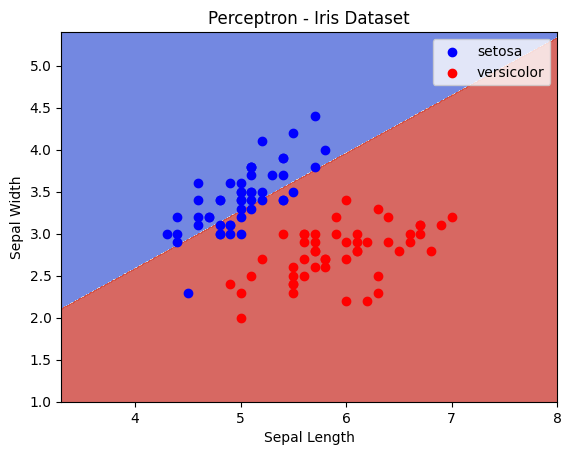

              precision    recall  f1-score   support

           0       1.00      0.71      0.83        17
           1       0.72      1.00      0.84        13

    accuracy                           0.83        30
   macro avg       0.86      0.85      0.83        30
weighted avg       0.88      0.83      0.83        30



In [5]:
# 4. Visualizar la región de decisión
#np.linspace genera una secuencia de números que están distribuidos uniformemente entre
#un valor inicial y un valor final, donde se especifica la cantidad de números en la secuencia.

xx, yy = np.meshgrid(np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 500),
                     np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 500))



Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.8, cmap="coolwarm")
plt.scatter(X[y == 0][:, 0], X[y== 0][:, 1], color="blue", label="setosa")
plt.scatter(X[y == 1][:, 0], X[y== 1][:, 1], color="red", label="versicolor")
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.legend()
plt.title("Perceptron - Iris Dataset")
plt.show()

print(classification_report(y_test,y_pred))


#### Recordemos:


---


**Precision (Precisión)**
Para cada clase:
* La precisión es la proporción de verdaderos positivos (TP) entre el total de positivos identificados (suma de verdaderos positivos y falsos positivos).
 $$Precision=\frac{TP}{TP+FP}$$

**Recall (Exhaustividad o Sensibilidad)**
Para cada clase:

* El recall o sensibilidad es la proporción de verdaderos positivos (TP) entre el total de casos positivos reales (suma de verdaderos positivos y falsos negativos).
 $$Recall = \frac{TP}{TP+FN}$$

**F1-score**
Para cada clase:

* Es una métrica que combina precisión y recall en un solo número usando la media armónica.

$$F1-{score}=2*\frac{Precision*Recall}{Precision+Recall}$$

**Support**
* El número de casos reales para cada clase en el conjunto de datos de prueba.


**Accuracy (Exactitud)**
* Es la proporción de predicciones correctas entre el total de predicciones.

$$Accuracy = \frac{\text{Número de predicciones correctas}}{\text{Número total de predicciones}}$$

**Macro avg**
* Es el promedio de la métrica (precisión, recall o f1-score) para todas las clases sin ponderar.
* Es útil cuando quieres tratar todas las clases por igual, independientemente de su tamaño. Por ejemplo, si todas las clases son igualmente importantes en un contexto, es posible que quieras usar la media macro para obtener un resumen del rendimiento del modelo.

**Weighted avg**
* Es el promedio ponderado de la métrica (precisión, recall o f1-score) para todas las clases. Se pondera según el "support" (número de instancias verdaderas) para cada clase.
* Es útil cuando tienes un desequilibrio de clases y quieres que las métricas de las clases con más muestras influyan más en el promedio total. Por ejemplo, si estás desarrollando un modelo de detección de fraude y una clase (no fraude) tiene muchas más muestras que la otra (fraude), podrías estar interesado en el promedio ponderado para entender mejor el rendimiento global del modelo.

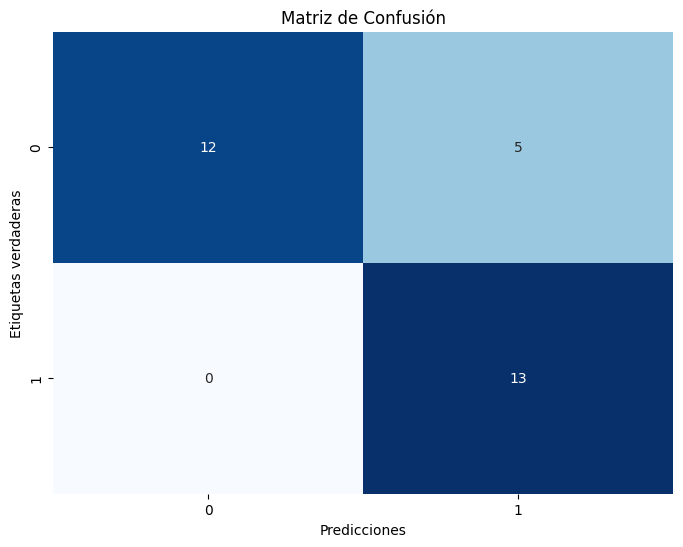

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Calculamos la matriz de confusión
# cm = confusion_matrix(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

# Creamos el mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.xlabel('Predicciones')
plt.ylabel('Etiquetas verdaderas')
plt.title('Matriz de Confusión')
plt.show()




Accuracy: 71.11%


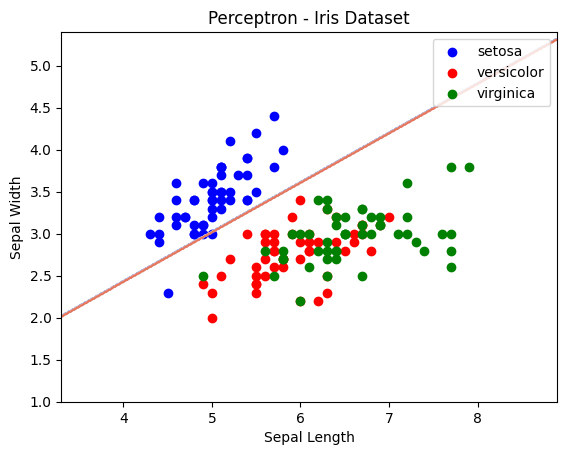

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.50      1.00      0.67        13
           2       0.00      0.00      0.00        13

    accuracy                           0.71        45
   macro avg       0.50      0.67      0.56        45
weighted avg       0.57      0.71      0.61        45



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


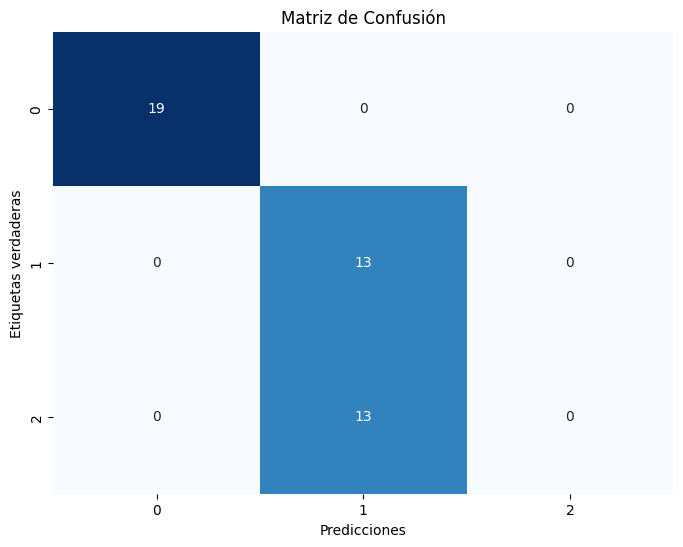

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. Cargar el conjunto de datos Iris
iris = datasets.load_iris()
X = iris.data
y = iris.target

# 2. Preparar el conjunto de datos
# Seleccionar setosa y versicolor (primeras 150 entradas) y solo dos características (longitud y ancho del sépalo)
X = X[:150, :2]
y = y[:150]

# Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Entrenar el Perceptrón
clf = Perceptron(max_iter=1000, tol=1e-3)
clf.fit(X_train, y_train)

# Predicciones
y_pred = clf.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

# 4. Visualizar la región de decisión
xx, yy = np.meshgrid(np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 500),
                     np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 500))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contour(xx, yy, Z, alpha=0.8, cmap="coolwarm")
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color="blue", label="setosa")
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color="red", label="versicolor")
plt.scatter(X[y == 2][:, 0], X[y == 2][:, 1], color="green", label="virginica")
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.legend()
plt.title("Perceptron - Iris Dataset")
plt.show()


print(classification_report(y_test,y_pred))


# Calculamos la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Creamos el mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.xlabel('Predicciones')
plt.ylabel('Etiquetas verdaderas')
plt.title('Matriz de Confusión')
plt.show()


### 🥇 Multi-Perceptrón (Red Neuronal Multicapa - MLP)

El Multi-Perceptrón, a menudo denominado Red Neuronal de Múltiples Capas (MLP), es una extensión del perceptrón simple que tiene una o más capas ocultas entre la entrada y la capa de salida.

* Compuesto por múltiples capas de neuronas. Cada capa está completamente conectada a la siguiente.
* Utiliza funciones de activación no lineales como sigmoide, tanh o ReLU.
* Puede aproximarse a funciones complejas gracias a la no linealidad introducida por estas activaciones y las capas ocultas.

El Perceptrón Multicapa (Multi-layer Perceptron, MLP) es un algoritmo de aprendizaje supervisado que aprende una función $f(⋅):R^m → R^o$  mediante el entrenamiento en un conjunto de datos, donde $m$  es el número de dimensiones de entrada y $o$ es el número de dimensiones de la salida. Dado un conjunto de características $X=x_1,x_2,...,X_m$ y un objetivo $y$
, puede aprender un aproximador de función no lineal para la clasificación o la regresión. Se diferencia de la regresión logística en que, entre la capa de entrada y la de salida, puede haber una o más capas no lineales, llamadas capas ocultas. La figura muestra un MLP de una capa oculta con salida escalar.

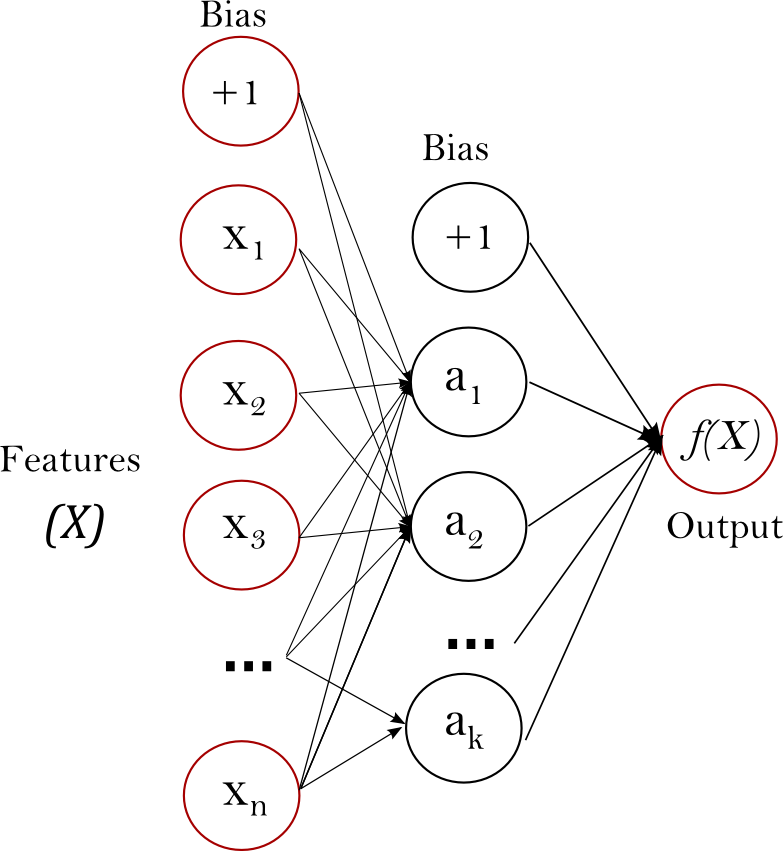

La capa más a la izquierda, conocida como la capa de entrada, consiste en un conjunto de neuronas que representan las características de entrada. Cada neurona en la capa oculta transforma los valores de la capa anterior con una suma lineal ponderada, seguida de una función de activación. La capa de salida recibe los valores de la última capa oculta y los transforma en valores de salida.


**Las ventajas del Perceptrón Multicapa son:**

* Capacidad para aprender modelos no lineales.

* Capacidad de aprender modelos en tiempo real (aprendizaje en línea) utilizando `partial_fit`.

**Las desventajas del Perceptrón Multicapa (MLP) incluyen:**

* Los MLP con capas ocultas tienen una función de pérdida no convexa en la que existe más de un mínimo local. Por lo tanto, diferentes inicializaciones de pesos aleatorios pueden conducir a una precisión de validación diferente.

* Los MLP requieren el ajuste de una serie de hiperparámetros, como el número de neuronas ocultas, las capas y las iteraciones.

* MLP es sensible al escalamiento de características.

## 🎯 Funciones de Activación o de Transferencia

---




Consideremos la siguente entrada de datos

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Lista de números
entradas = entradas = np.linspace(-10, 10, 200)
#np.array([-2, -1, 0, 1, 2])


### **Función umbral binaria**

Esta función crea neuronas que clasifican las
entradas en dos categorías diferentes: 0 y 1

In [9]:
def funcion_umbral(x, theta=0):
    return np.where(x >= theta, 1, 0)

/tmp/ipython-input-10-1392420673.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


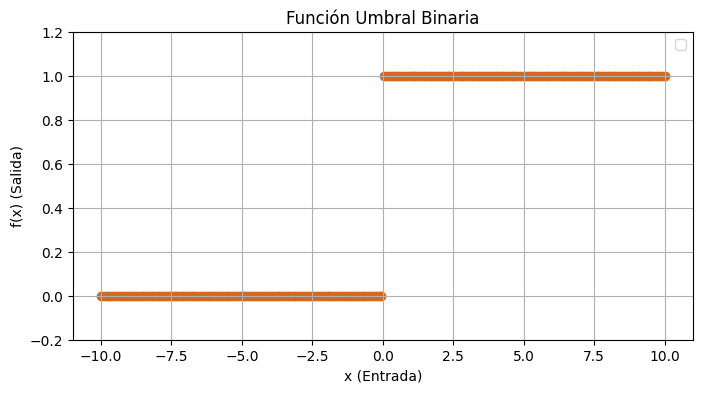

In [10]:
# Aplicar función
salidas = funcion_umbral(entradas)
print(salidas)


# Gráfico
plt.figure(figsize=(8, 4))
plt.scatter (entradas,salidas , color='chocolate')
#plt.plot(entradas,salidas , color='purple')
#plt.axvline(0, color='gray', linestyle='--', label='Umbral θ = 0')
plt.title('Función Umbral Binaria')
plt.xlabel('x (Entrada)')
plt.ylabel('f(x) (Salida)')
plt.ylim(-0.2, 1.2)
plt.grid(True)
plt.legend()
plt.show()

### **Umbral Bipolar**

Esta función crea neuronas que clasifican las
entradas en dos categorías diferentes: 1 y -1

In [11]:
def umbral_Bipolar(x, theta=0):
    return np.where(x >= theta, 1, -1)

[-1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1]


/tmp/ipython-input-12-1442102957.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


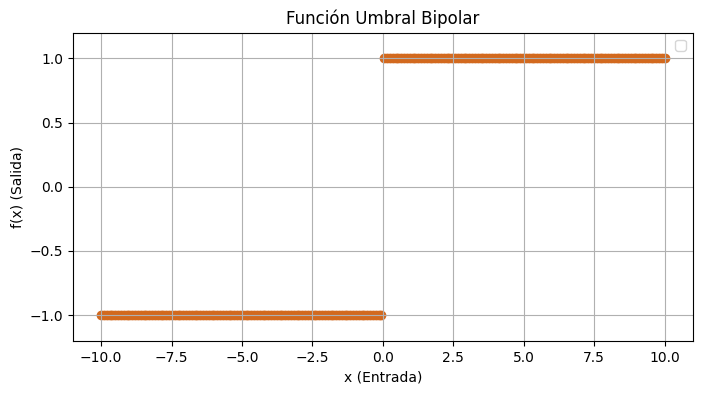

In [12]:
# Aplicar función
salidas = umbral_Bipolar(entradas)
print(salidas)

# Gráfico
plt.figure(figsize=(8, 4))
plt.scatter (entradas,salidas , color='chocolate')
#plt.plot(entradas,salidas , color='purple')
#plt.axvline(0, color='gray', linestyle='--', label='Umbral θ = 0')
plt.title('Función Umbral Bipolar')
plt.xlabel('x (Entrada)')
plt.ylabel('f(x) (Salida)')
plt.ylim(-1.2, 1.2)
plt.grid(True)
plt.legend()
plt.show()

### **Sigmoide (Logística)**
Muy usada en el mundo del Deep Learning y el Machine Learning, sobre todo para problemas de clasificación binaria. Su formula es:

$$
f(x)= \frac{1}{1+e^{-x}}
$$

In [13]:
def sigmoide(x):
  return 1 / (1 + np.exp(-x))


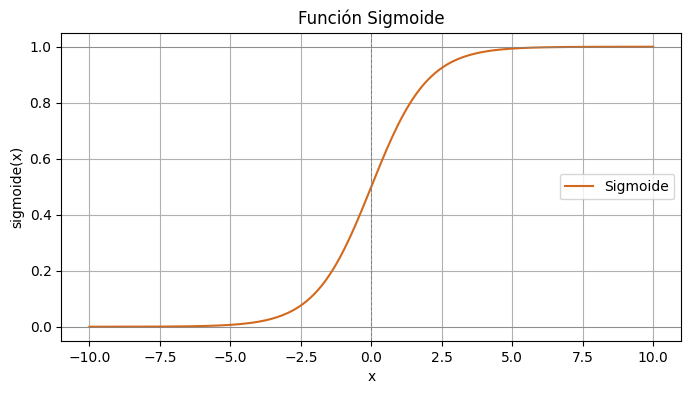

In [14]:
salidas = sigmoide(entradas)

# Graficar
plt.figure(figsize=(8, 4))
plt.plot(entradas, salidas, label='Sigmoide', color='chocolate')
plt.title("Función Sigmoide")
plt.xlabel("x")
plt.ylabel("sigmoide(x)")
plt.grid(True)
plt.axhline(0, color='gray', linewidth=0.5)
plt.axhline(1, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.7)
plt.legend()
plt.show()

In [15]:
import numpy as np
1 / (1 + np.exp(-1))

np.float64(0.7310585786300049)

### **RELU**

RELU (Rectificador Lineal Unitario), probablemente la más usada en el mundo del Deep Learning, sobre todo en la clasificación de imágenes, su formula matemática es sencillísima:

$$
f(x)=max(0,x)
$$


In [16]:
def relu(x):
    return np.maximum(0, x)

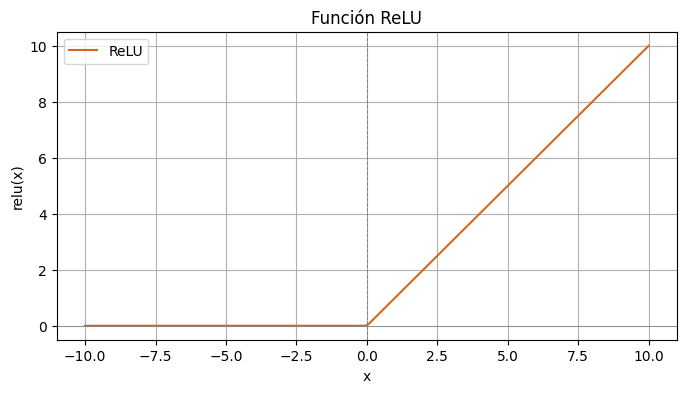

In [17]:
salidas = relu(entradas)

# Graficar
plt.figure(figsize=(8, 4))
plt.plot(entradas, salidas, label='ReLU', color='chocolate')
plt.title("Función ReLU")
plt.xlabel("x")
plt.ylabel("relu(x)")
plt.grid(True)
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.7)
plt.legend()
plt.show()

### **RELU6**
La función RELU, tiene bastantes variantes, esta es una de ellas. Es muy parecida por lo que voy a resumir bastante.

$$
f(x)=min(max(0,x),6)
$$

Básicamente si el valor es menor que cero, lo convierte a cero y si es mayor que seis, lo convierte a seis, si es cualquier valor entre cero y seis, queda dicho valor. Su gráfica es:

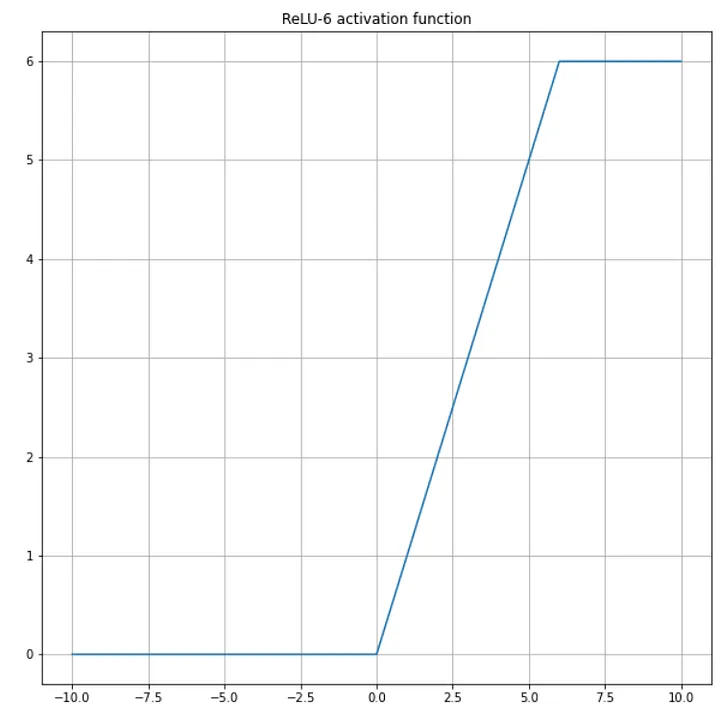


### **Tangente Hiperbólica**


Es parecida a la sigmoide, pero tiene una parte negativa, su formula es:

$$
f(x)=tanh(x)=\frac{sinh(x)}{cosh(x)}=\frac{e^x-e^{-x}}{e^x+e^{-x}}
$$

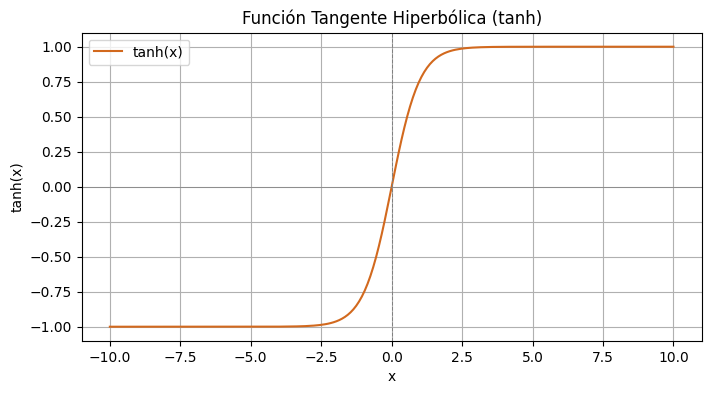

In [18]:
salidas = np.tanh(entradas)

# Graficar
plt.figure(figsize=(8, 4))
plt.plot(entradas, salidas, label='tanh(x)', color='chocolate')
plt.title("Función Tangente Hiperbólica (tanh)")
plt.xlabel("x")
plt.ylabel("tanh(x)")
plt.grid(True)
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.7)
plt.legend()
plt.show()

### **Softsign**


Es parecida a la tangente hiperbólica, sus valores van de -1 a 1. Es más suavizada que la tangente hiperbólica. Su función es muy fácil:

$$
f(x)=\frac{x}{|x|+1}
$$

Su gráfica muy parecida a la de la tangente hiperbólica, pero más suavizada. Mientras que *tanh* converge exponencialmente, *softsign* lo hace polinomialmente.

Aquí podemos ver ambas:

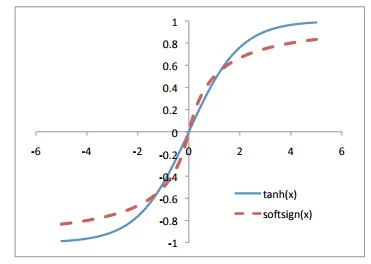

**Propiedades matemáticas:**

* Es continua
* La derivada no es derivable en x=0
* Va de -1 a 1
* Es una función impar

*Softsign* previene a las neuronas de que se saturen, por lo que suele producir un entrenamiento más efectivo. Sin embargo, debido a las derivadas más comlejas de calcular, resulta ser más costoso su cómputo que la *tanh*.

El código sería la siguiente:

### **Softplus**
Es la función continua y derivable de la función RELU. Esto se consigue mediante el logaritmo. Esta es su función.

$$
f(x)=ln(e^x+1)
$$

Su gráfica es parecida a la RELU, pero más suavizada, aquí están las dos, para poder compararlas.

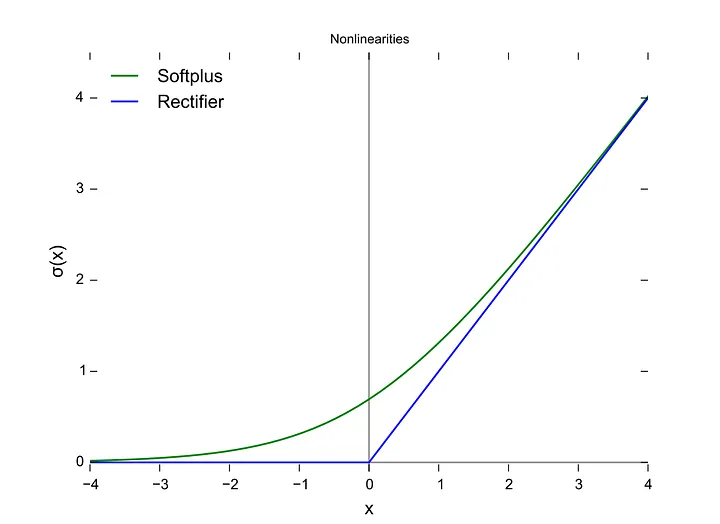

**Propiedades matemáticas:**

* Es continua
* Es derivable (RELU no lo era)
* Va de 0 a ∞

Su codificación es la siguiente:



### **ELU**
Es similar a la RELU, lo único que los valores negativos forman una asíntota horizontal hacia -1. Su función la podemos definir así:

\begin{cases}
 f(x)=e^x-1& \text{ si} x<0 \\
 f(x)=x& \text{ si} x>=0
\end{cases}

Si $x$ es menor que cero, elevamos el número irracional $e$ a la $x$ y le restamos 1, si es igual o mayor que cero quedamos el mismo valor. Su gráfica es parecida a la RELU:

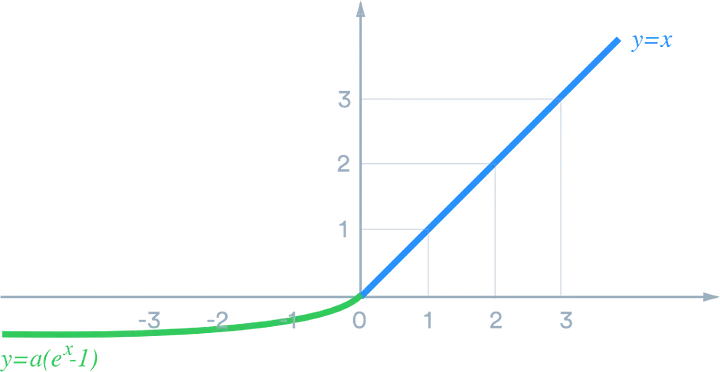


### Softmax



En clasificación, sirve para cuando tenemos múltiples clases y queremos extraer la probabilidad según los datos de pertenecer a las distintas clases posibles. Hay muchas variantes, su formula es:

$$
s(x)_j=\frac{e^{x_j}}{\sum_{k=1}^{K}{e^{x_k}}}
$$
Para $j=1, ..., K$

Para esta versión de la Softmax, las categorías son excluyentes, es decir, si se asigna una categoría, ya no se puede pertenecer a otra.

Normalmente esta función es usada en la capa final de la red neuronal, para realizar la predicción de dicha red neuronal. Su función en Python sería así:

In [19]:
import numpy as np

def softmax(x):
    return np.exp(x) / np.sum(np.exp(x), axis=0)

### En resumen


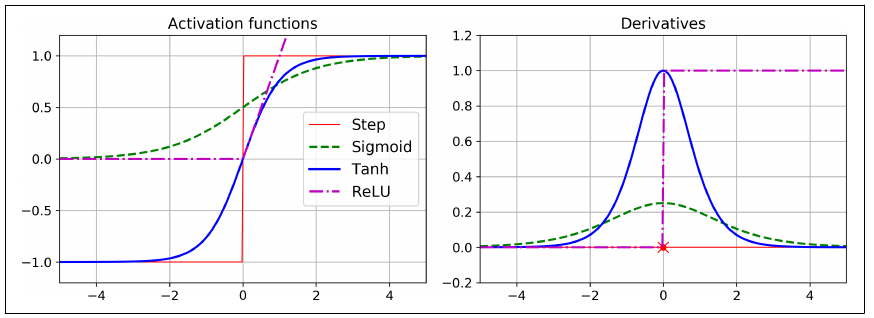

Buen artículo donde compara y analiza cada función: https://arxiv.org/pdf/2010.09458

## Modelos de Clasificación

La clase [MLPClassifier](https://qu4nt.github.io/sklearn-doc-es/modules/generated/sklearn.neural_network.MLPClassifier.html#sklearn.neural_network.MLPClassifier) de sklearn implementa un algoritmo de perceptrón multicapa (MLP) que se entrena utilizando Retropropagación (Backpropagation).

El MLP se entrena en dos arreglos: el arreglo $X$ de tamaño `(n_samples, n_features)`, que contiene las muestras de entrenamiento representadas como vectores de características de punto flotante; y el arreglo $y$ de tamaño `(n_samples,)`, que contiene los valores objetivo (etiquetas de clase) para las muestras de entrenamiento.

Retomemos el ejemplo de Iris

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Cargar el conjunto de datos Iris
iris = datasets.load_iris()
X = iris.data
y = iris.target

# 2. Preparar el conjunto de datos
X = X[:150, :2]
y = y[:150]

# Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


Accuracy: 86.67%


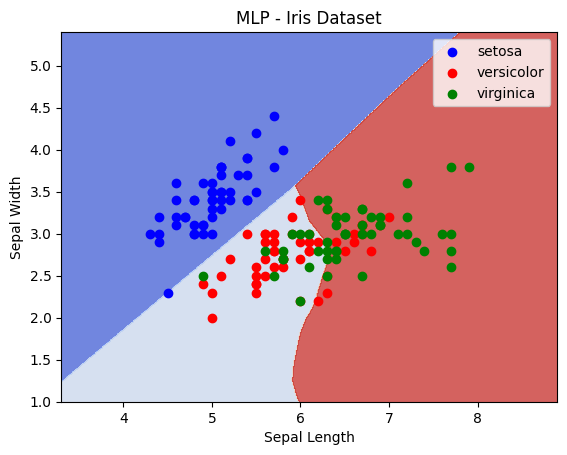

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.86      0.67      0.75         9
           2       0.77      0.91      0.83        11

    accuracy                           0.87        30
   macro avg       0.88      0.86      0.86        30
weighted avg       0.87      0.87      0.86        30



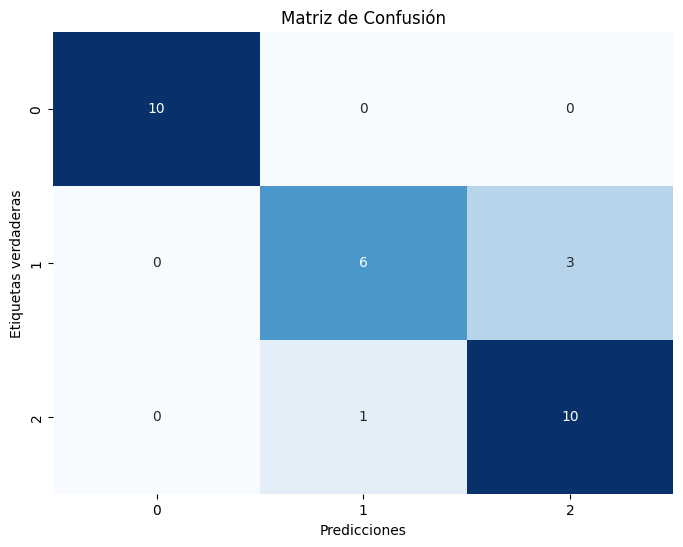

In [21]:
# 3. Entrenar el MLP
mlp = MLPClassifier(hidden_layer_sizes=(100,150,), max_iter=300, activation='relu', random_state=42)
mlp.fit(X_train, y_train)


# Predicciones
y_pred = mlp.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

# 4. Visualizar la región de decisión
xx, yy = np.meshgrid(np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 500),
                     np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 500))
Z = mlp.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.8, cmap="coolwarm")
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color="blue", label="setosa")
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color="red", label="versicolor")
plt.scatter(X[y == 2][:, 0], X[y == 2][:, 1], color="green", label="virginica")
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.legend()
plt.title("MLP - Iris Dataset")
plt.show()

print(classification_report(y_test,y_pred))

# Calculamos la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Creamos el mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.xlabel('Predicciones')
plt.ylabel('Etiquetas verdaderas')
plt.title('Matriz de Confusión')
plt.show()

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


Accuracy: 83.33%


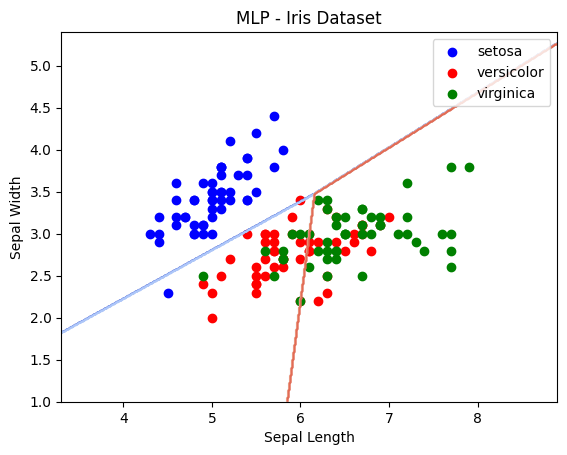

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.83      0.56      0.67         9
           2       0.71      0.91      0.80        11

    accuracy                           0.83        30
   macro avg       0.85      0.82      0.82        30
weighted avg       0.85      0.83      0.83        30



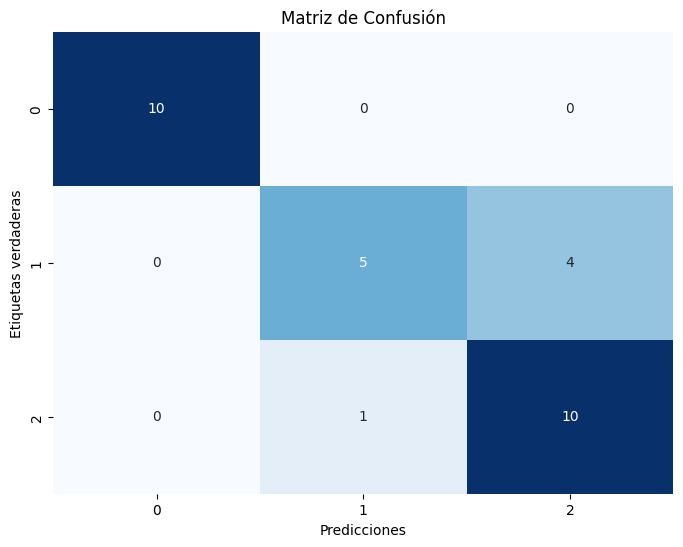

In [22]:

# 3. Entrenar el MLP
mlp = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, activation='identity', random_state=42)
mlp.fit(X_train, y_train)

# Predicciones
y_pred = mlp.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

# 4. Visualizar la región de decisión
xx, yy = np.meshgrid(np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 500),
                     np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 500))
Z = mlp.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contour(xx, yy, Z, alpha=0.8, cmap="coolwarm")
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color="blue", label="setosa")
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color="red", label="versicolor")
plt.scatter(X[y == 2][:, 0], X[y == 2][:, 1], color="green", label="virginica")
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.legend()
plt.title("MLP - Iris Dataset")
plt.show()

print(classification_report(y_test,y_pred))

# Calculamos la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Creamos el mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.xlabel('Predicciones')
plt.ylabel('Etiquetas verdaderas')
plt.title('Matriz de Confusión')
plt.show()

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


Accuracy: 90.00%


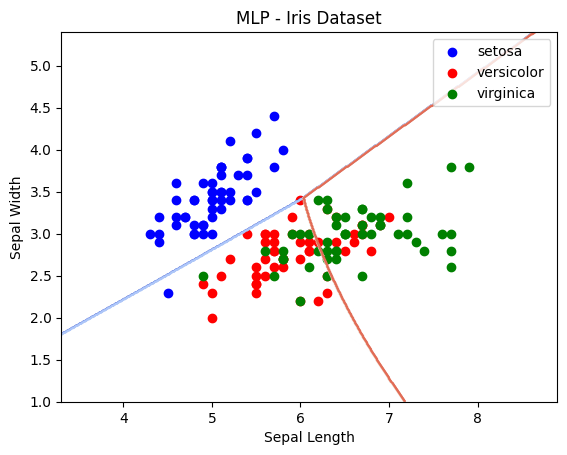

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.88      0.78      0.82         9
           2       0.83      0.91      0.87        11

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



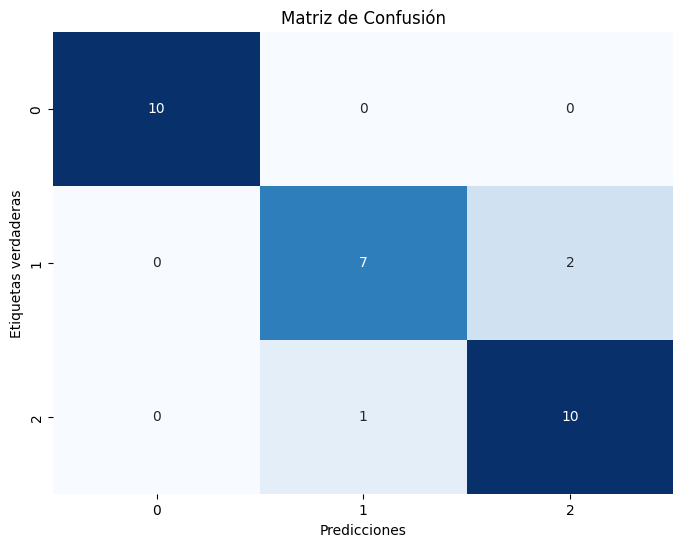

In [23]:

# 3. Entrenar el MLP
mlp = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, activation='tanh', random_state=42)
mlp.fit(X_train, y_train)

# Predicciones
y_pred = mlp.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

# 4. Visualizar la región de decisión
xx, yy = np.meshgrid(np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 500),
                     np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 500))
Z = mlp.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contour(xx, yy, Z, alpha=0.8, cmap="coolwarm")
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color="blue", label="setosa")
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color="red", label="versicolor")
plt.scatter(X[y == 2][:, 0], X[y == 2][:, 1], color="green", label="virginica")
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.legend()
plt.title("MLP - Iris Dataset")
plt.show()

print(classification_report(y_test,y_pred))

# Calculamos la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Creamos el mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.xlabel('Predicciones')
plt.ylabel('Etiquetas verdaderas')
plt.title('Matriz de Confusión')
plt.show()

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


Accuracy: 90.00%


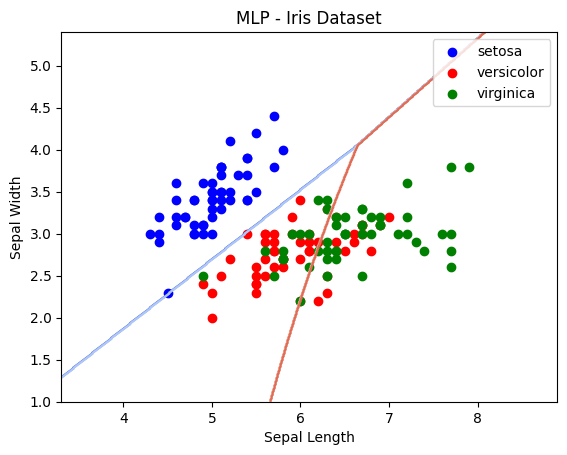

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.88      0.78      0.82         9
           2       0.83      0.91      0.87        11

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



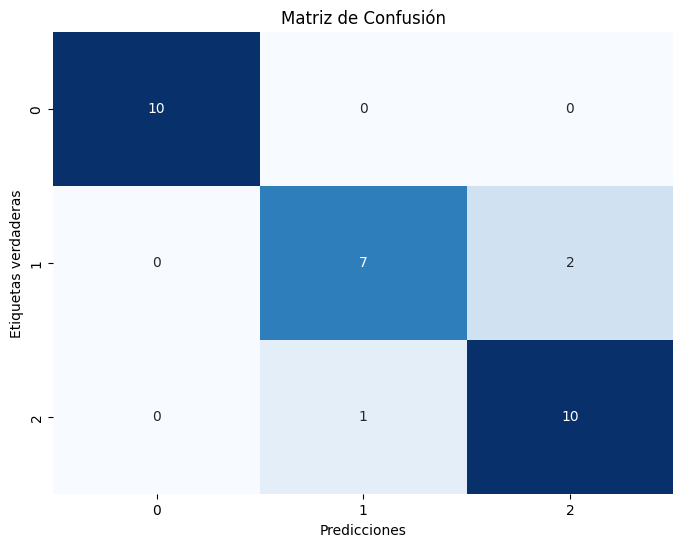

In [24]:

# 3. Entrenar el MLP
mlp = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, activation='logistic', random_state=42)
mlp.fit(X_train, y_train)

# Predicciones
y_pred = mlp.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

# 4. Visualizar la región de decisión
xx, yy = np.meshgrid(np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 500),
                     np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 500))
Z = mlp.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contour(xx, yy, Z, alpha=0.8, cmap="coolwarm")
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color="blue", label="setosa")
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color="red", label="versicolor")
plt.scatter(X[y == 2][:, 0], X[y == 2][:, 1], color="green", label="virginica")
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.legend()
plt.title("MLP - Iris Dataset")
plt.show()

print(classification_report(y_test,y_pred))

# Calculamos la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Creamos el mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.xlabel('Predicciones')
plt.ylabel('Etiquetas verdaderas')
plt.title('Matriz de Confusión')
plt.show()

## Modelos de Regresión

La clase [MLPRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPRegressor.html#sklearn.neural_network.MLPRegressor) de sklearn implementa un algoritmo de perceptrón multicapa (MLP) que se entrena utilizando Retropropagación (Backpropagation) para problemas de regresión.

El `MLPRegressor` se entrena en dos arreglos: el arreglo $X$ de tamaño `(n_samples, n_features)`, que contiene las muestras de entrenamiento representadas como vectores de características de punto flotante; y el arreglo $y$ de tamaño `(n_samples,)`, que contiene los valores objetivo reales (valores numéricos) para las muestras de entrenamiento.

A diferencia del `MLPRegressor` que está diseñado para clasificación y produce etiquetas de clase como salida, el `MLPRegressor` está diseñado para problemas de regresión y produce valores numéricos continuos como salida.
Para más información [redes neuronales supervisada](https://scikit-learn.org/stable/modules/neural_networks_supervised.html])